# Faces/basic ECoG workflow

Shareable notebook for one subject. Main analysis runs here. Terminal scripts are used only for interactive checks.


## Terminal tools

Run these from the folder that contains this notebook.

```powershell
cd <folder-containing-this-notebook>
```

`inspect_raw.py`: interactive raw viewer. Change time, channel count, amplitude scale; click channels to mark bad; saves `*_bad_channels.txt`.

```powershell
python inspect_raw.py "<path-to-subject>\aa_faceshouses.mat"
```

`plot_aa_psd.py`: plots frequency spectrum before/after notch at `60, 120, 180, 240 Hz`. It does not change the data file.

```powershell
python plot_aa_psd.py "<path-to-subject>\aa_faceshouses.mat"
```

`save_notched_mat.py`: saves a filtered copy next to the original as `*_notch60.mat`.

```powershell
python save_notched_mat.py "<path-to-subject>\aa_faceshouses.mat"
```


## Setup

Edit `DATA_FILE` for the subject you want to analyze. Use the original `*_faceshouses.mat`; the notebook will use `*_notch60.mat` if it exists.


In [ ]:
%matplotlib inline

# Show Matplotlib figures inside the notebook.
# Do not use `%matplotlib qt` here; Qt is only needed for separate interactive windows.

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import butter, filtfilt, hilbert

# Path to the original subject file.
# For another subject or another computer, change only this path.
# Change this to the subject file on your computer.
# Example: Path(r"C:\Users\yourname\Downloads\faces_basic\faces_basic\data\aa\aa_faceshouses.mat")
DATA_FILE = Path(r"<CHANGE_ME>\aa_faceshouses.mat")

# Subject name is taken from the file name:
# aa_faceshouses.mat -> aa
SUBJECT = DATA_FILE.stem.replace("_faceshouses", "")

# Expected path to the notch-filtered copy.
# This file is created by running save_notched_mat.py from the terminal.
NOTCHED_FILE = DATA_FILE.with_name(DATA_FILE.stem + "_notch60" + DATA_FILE.suffix)

# Expected path to the manually marked bad-channel list.
# This file is created by inspect_raw.py when you click bad channels and press "Save bads".
BAD_FILE = DATA_FILE.with_name(f"{SUBJECT}_bad_channels.txt")

# Print all paths so it is clear what this notebook will use.
print("Subject:", SUBJECT)
print("Original:", DATA_FILE)
print("Notched:", NOTCHED_FILE)
print("Bad channels file:", BAD_FILE)


Subject: aa
Original: C:\Users\sereg\Downloads\faces_basic\faces_basic\data\aa\aa_faceshouses.mat
Notched: C:\Users\sereg\Downloads\faces_basic\faces_basic\data\aa\aa_faceshouses_notch60.mat
Bad channels file: C:\Users\sereg\Downloads\faces_basic\faces_basic\data\aa\aa_bad_channels.txt


## Load filtered data and bad channels

If `*_notch60.mat` is missing, run `save_notched_mat.py` first or this notebook will use the original file.


In [2]:
analysis_file = NOTCHED_FILE if NOTCHED_FILE.exists() else DATA_FILE
if analysis_file == DATA_FILE:
    print("WARNING: notched file not found; using original data.")
    print("Run: python save_notched_mat.py", str(DATA_FILE))

mat = loadmat(analysis_file, squeeze_me=True)
data = np.asarray(mat["data"], dtype=float).T  # channels x time
stim = np.asarray(mat["stim"]).astype(int)
srate = float(mat["srate"])

if BAD_FILE.exists():
    bads = [line.strip() for line in BAD_FILE.read_text(encoding="utf-8").splitlines() if line.strip()]
else:
    bads = []

bad_idx = [int(ch.replace("EEG", "")) for ch in bads]
good_idx = [i for i in range(data.shape[0]) if i not in bad_idx]
data_good = data[good_idx]
good_names = [f"EEG{i}" for i in good_idx]

print("Analysis file:", analysis_file)
print("Sampling rate:", srate, "Hz")
print("Data shape:", data.shape, "channels x time")
print("Bad channels:", bads if bads else "none")
print("Good channels:", len(good_idx))


Analysis file: C:\Users\sereg\Downloads\faces_basic\faces_basic\data\aa\aa_faceshouses_notch60.mat
Sampling rate: 1000.0 Hz
Data shape: (46, 271400) channels x time
Bad channels: ['EEG0', 'EEG15', 'EEG20', 'EEG25']
Good channels: 42


## CAR reference

Common average reference over good channels only.


In [4]:
data_car = data_good - data_good.mean(axis=0, keepdims=True)
print("CAR data shape:", data_car.shape)


CAR data shape: (42, 271400)


## Broadband / high-gamma

Compute broadband log power in `70-150 Hz`.


In [5]:
LOW, HIGH = 70, 150

b, a = butter(N=4, Wn=[LOW, HIGH], btype="bandpass", fs=srate)
hg = filtfilt(b, a, data_car, axis=1)

bb_amp = np.abs(hilbert(hg, axis=1))
bb_log_power = np.log(bb_amp ** 2 + 1e-12)

print("Broadband log-power shape:", bb_log_power.shape)


Broadband log-power shape: (42, 271400)


## Events

Stimulus codes `1-50` are houses; `51-100` are faces.


In [6]:
is_picture = (stim >= 1) & (stim <= 100)
event_onsets = np.flatnonzero(is_picture & np.r_[True, stim[1:] != stim[:-1]])
event_codes = stim[event_onsets]

house_events = event_onsets[(event_codes >= 1) & (event_codes <= 50)]
face_events = event_onsets[(event_codes >= 51) & (event_codes <= 100)]

print("House events:", len(house_events))
print("Face events:", len(face_events))


House events: 150
Face events: 150


## Epoch broadband around stimulus

Baseline correction uses `-200..0 ms`.


In [7]:
tmin, tmax = -0.2, 0.8
samples = np.arange(int(tmin * srate), int(tmax * srate))
times = samples / srate
baseline_mask = (times >= -0.2) & (times < 0)

def make_epochs(signal, events):
    epochs = []
    for ev in events:
        idx = ev + samples
        if idx[0] >= 0 and idx[-1] < signal.shape[1]:
            ep = signal[:, idx]
            baseline = ep[:, baseline_mask].mean(axis=1, keepdims=True)
            epochs.append(ep - baseline)
    return np.asarray(epochs)  # epochs x channels x time

face_epochs = make_epochs(bb_log_power, face_events)
house_epochs = make_epochs(bb_log_power, house_events)

print("Face epochs:", face_epochs.shape)
print("House epochs:", house_epochs.shape)


Face epochs: (150, 42, 1000)
House epochs: (150, 42, 1000)


## Plot face vs house broadband


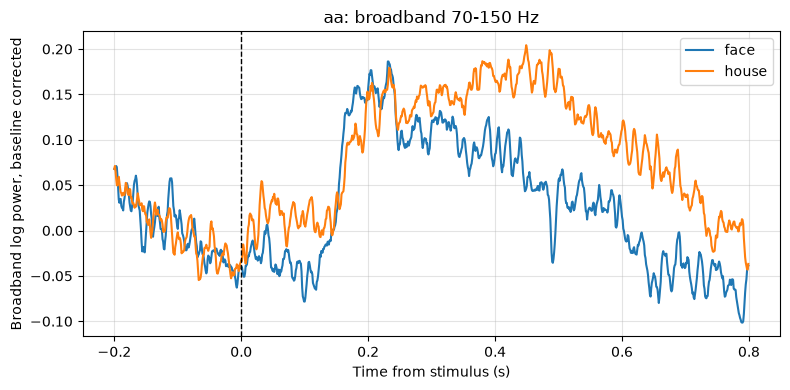

In [8]:
plt.close("all")

face_mean = face_epochs.mean(axis=(0, 1))
house_mean = house_epochs.mean(axis=(0, 1))

plt.figure(figsize=(8, 4))
plt.plot(times, face_mean, label="face")
plt.plot(times, house_mean, label="house")
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Time from stimulus (s)")
plt.ylabel("Broadband log power, baseline corrected")
plt.title(f"{SUBJECT}: broadband {LOW}-{HIGH} Hz")
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()


## Next steps

Use the same epochs for electrode-level plots, ERP, time-frequency, and face-vs-house decoding.
